# IEEE-CIS Fraud Detection — EDA (Transaction Data)
**Goal:** Understand the dataset before building any pipeline 

Covers:
- Shape, dtypes, missing values
- Class imbalance
- Feature distributions & outliers
- Correlation heatmap
- Transaction patterns (time, amount)
- Feature keep/drop decisions

## 0. Imports & Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')



print('Libraries loaded ✓')

Libraries loaded ✓


In [62]:
import pandas as pd
import numpy as np

# ── Load train and test separately ──────────────────────────────
train_tx = pd.read_csv("data/train_transaction.csv")
test_tx  = pd.read_csv("data/test_transaction.csv")

# ── Add source tag ───────────────────────────────────────────────
train_tx['source'] = 'train'
test_tx['source']  = 'test'

# test has no target column — add as NaN so concat works cleanly
test_tx['isFraud'] = np.nan

# ── Combine ──────────────────────────────────────────────────────
df = pd.concat([train_tx, test_tx], axis=0, ignore_index=True)

In [63]:
# ── Save as parquet ──────────────────────────────────────────────
df.to_parquet("data/transaction.parquet", index=False)

print(f'Train transaction : {train_tx.shape}')
print(f'Test transaction  : {test_tx.shape}')
print(f'Combined          : {df.shape}')
print(f'Source counts     :\n{df["source"].value_counts()}')
print('Saved → data/transaction.parquet ✓')


Train transaction : (590540, 395)
Test transaction  : (506691, 395)
Combined          : (1097231, 395)
Source counts     :
source
train    590540
test     506691
Name: count, dtype: int64
Saved → data/transaction.parquet ✓


## 1. Load Data

In [2]:
# df = pd.read_csv("data\\transaction.csv")
# df.to_parquet("data\\transaction.parquet")
# #df = pd.read_csv(r'data/transaction.csv')

In [64]:
df = pd.read_parquet("data\\transaction.parquet")

## 2. Shape, Dtypes & Basic Info

In [65]:
dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ['dtype', 'count']
print('--- Data Types Summary ---')
print(dtype_summary.to_string(index=False))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nNumeric columns    : {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'Categorical cols   : {cat_cols}')

--- Data Types Summary ---
  dtype  count
float64    377
 object     15
  int64      3

Numeric columns    : 380
Categorical columns: 15
Categorical cols   : ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'source']


## 3. Missing Values Analysis

In [66]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : (df.isnull().sum() / len(df)) * 100
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print(f'Columns with missing values: {len(missing)} / {df.shape[1]}')
print(f'\nTop 20 columns by missing %:')
print(missing.head(20).to_string())

Columns with missing values: 389 / 395

Top 20 columns by missing %:
       missing_count  missing_pct
dist2        1023168      93.2500
D7            998181      90.9727
D12           963260      87.7901
D8            947967      86.3963
D9            947967      86.3963
V138          939501      85.6247
V139          939501      85.6247
V141          939501      85.6247
V142          939501      85.6247
V146          939501      85.6247
V147          939501      85.6247
V148          939501      85.6247
V149          939501      85.6247
V154          939501      85.6247
V140          939501      85.6247
V155          939501      85.6247
V158          939501      85.6247
V163          939501      85.6247
V162          939501      85.6247
V161          939501      85.6247


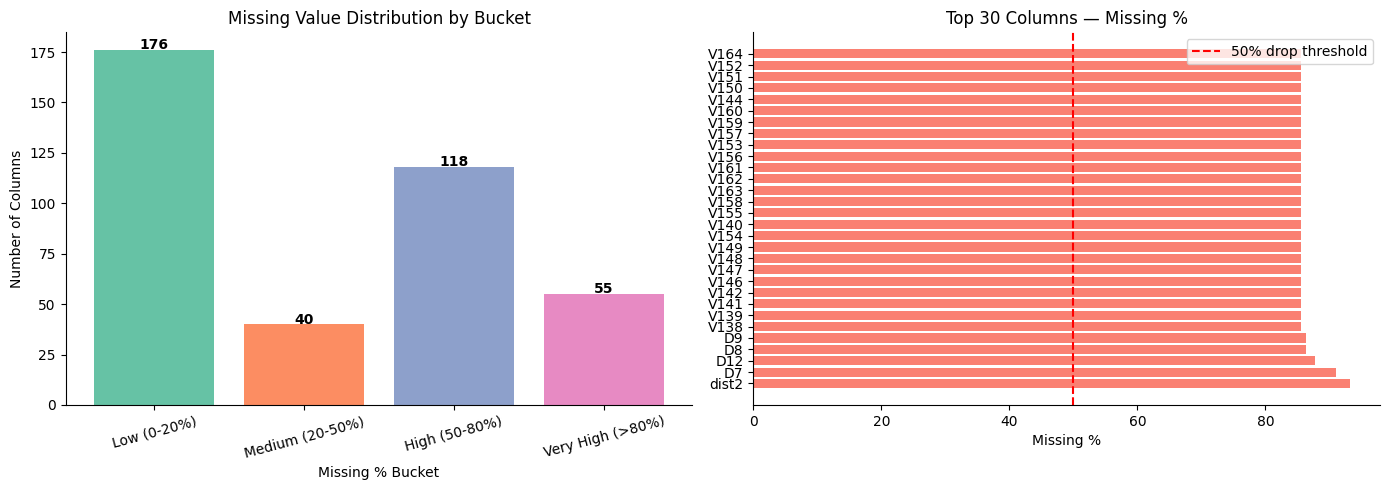

Decision: DROP 173 columns with >50% missing


In [67]:
buckets = {
    'Low (0-20%)'     : ((missing['missing_pct'] > 0)  & (missing['missing_pct'] <= 20)).sum(),
    'Medium (20-50%)' : ((missing['missing_pct'] > 20) & (missing['missing_pct'] <= 50)).sum(),
    'High (50-80%)'   : ((missing['missing_pct'] > 50) & (missing['missing_pct'] <= 80)).sum(),
    'Very High (>80%)': (missing['missing_pct'] > 80).sum(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(buckets.keys(), buckets.values(), color=sns.color_palette('Set2'))
axes[0].set_title('Missing Value Distribution by Bucket')
axes[0].set_xlabel('Missing % Bucket')
axes[0].set_ylabel('Number of Columns')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(buckets.values()):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

top30 = missing.head(30)
axes[1].barh(top30.index, top30['missing_pct'], color='salmon')
axes[1].axvline(x=50, color='red', linestyle='--', label='50% drop threshold')
axes[1].set_title('Top 30 Columns — Missing %')
axes[1].set_xlabel('Missing %')
axes[1].legend()

plt.tight_layout()
plt.show()

drop_cols = missing[missing['missing_pct'] > 50].index.tolist()
print(f'Decision: DROP {len(drop_cols)} columns with >50% missing')

## 4. Class Imbalance

--- Target: isFraud ---
Not Fraud (0): 569,877  (96.50%)
Fraud     (1): 20,663  (3.50%)
Imbalance ratio: 27.6:1


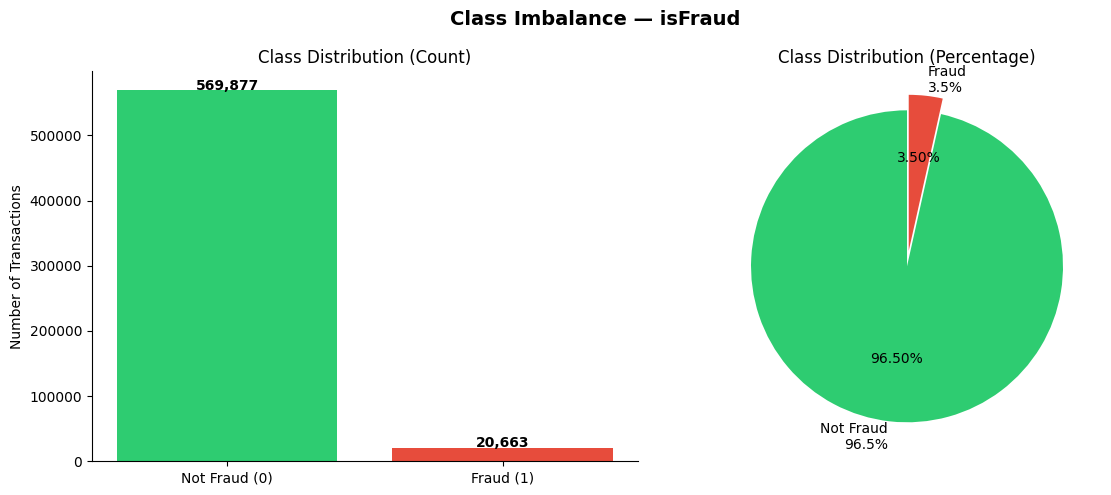


IMPORTANT: Use ROC-AUC + F1, NOT accuracy!


In [84]:
# In your class imbalance cell — add this one line
fraud_counts = df[df['source']=='train']['isFraud'].value_counts()
fraud_pct    = df[df['source']=='train']['isFraud'].value_counts(normalize=True) * 100

print('--- Target: isFraud ---')
print(f'Not Fraud (0): {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)')
print(f'Fraud     (1): {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)')
print(f'Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    fraud_counts.values,
    labels=[f'Not Fraud\n{fraud_pct[0]:.1f}%', f'Fraud\n{fraud_pct[1]:.1f}%'],
    colors=colors, explode=(0, 0.1), autopct='%1.2f%%', startangle=90
)
axes[1].set_title('Class Distribution (Percentage)')

plt.suptitle('Class Imbalance — isFraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nIMPORTANT: Use ROC-AUC + F1, NOT accuracy!')

## 5. Transaction Amount Analysis

--- TransactionAmt Stats by Class ---
              count     mean      std    min     25%     50%      75%  \
isFraud                                                                 
0.0000  569877.0000 134.5100 239.4000 0.2500 43.9700 68.5000 120.0000   
1.0000   20663.0000 149.2400 232.2100 0.2900 35.0400 75.0000 161.0000   

               max  
isFraud             
0.0000  31937.3900  
1.0000   5191.0000  


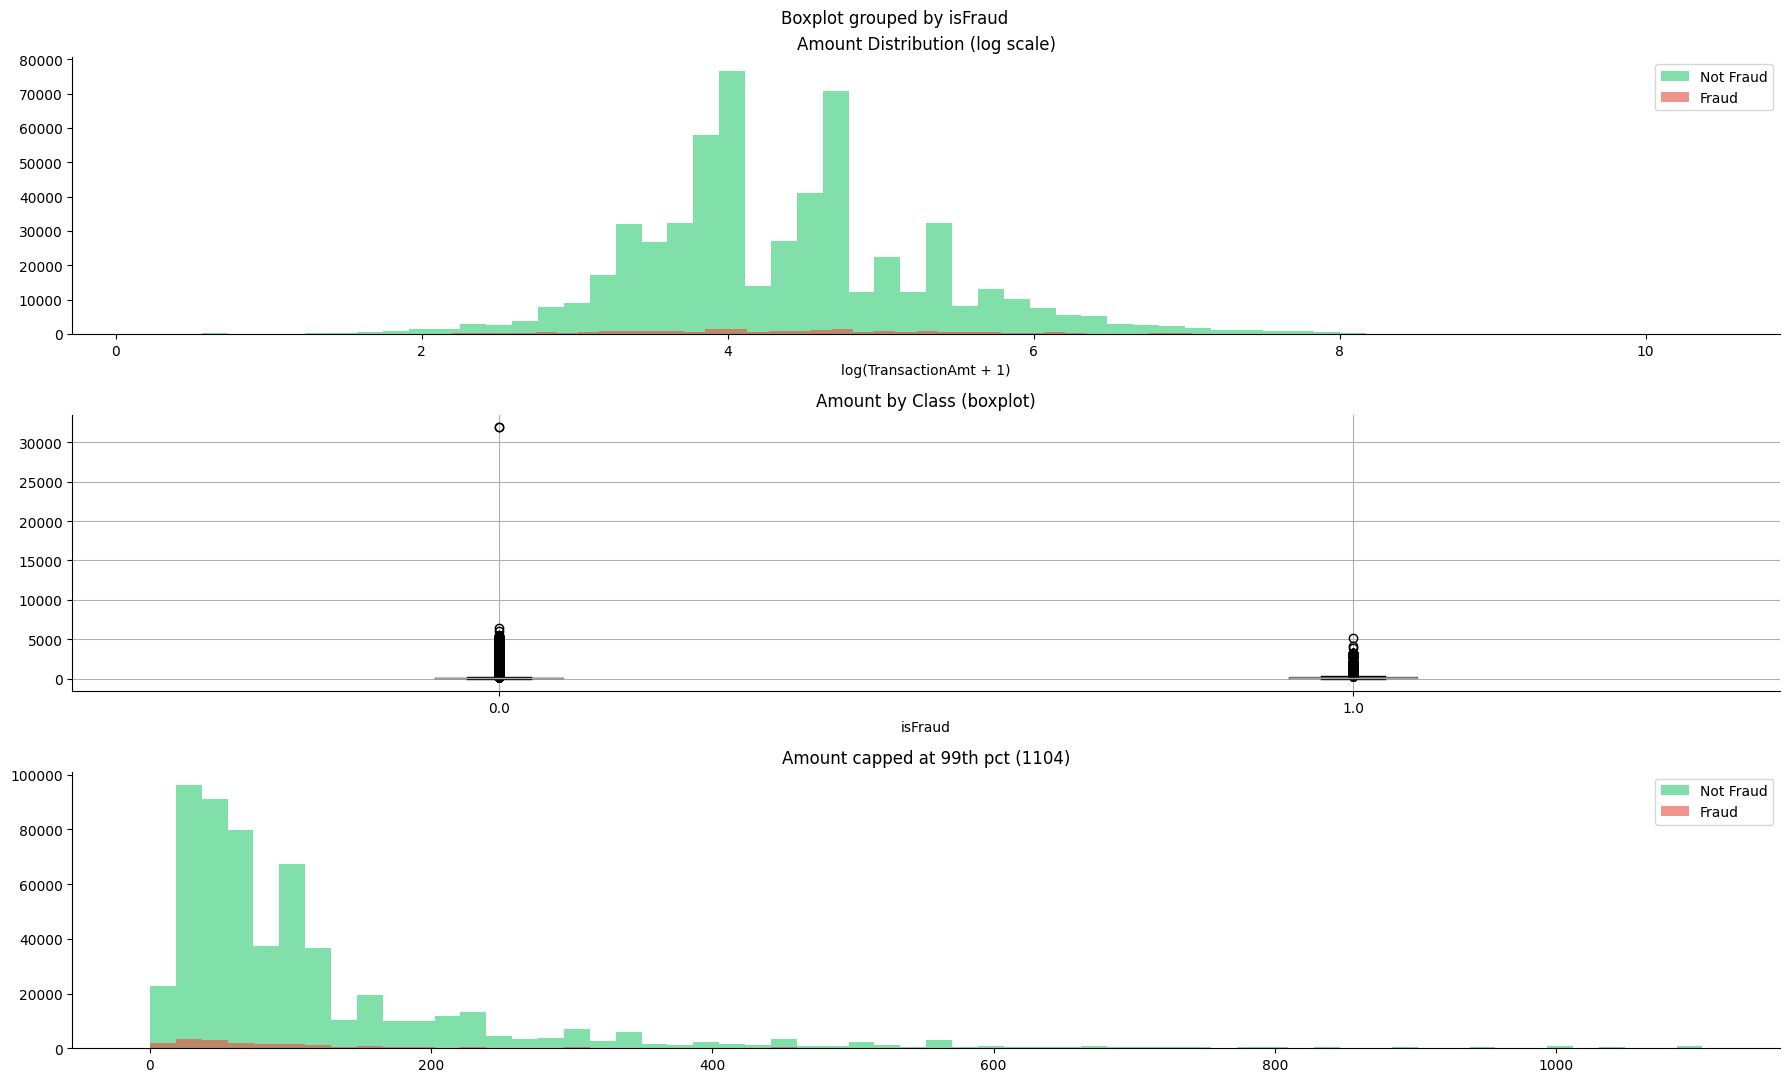

In [85]:
print('--- TransactionAmt Stats by Class ---')
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

fig, axes = plt.subplots(3,1 , figsize=(18, 11))
fraud    = df[df['isFraud'] == 1]['TransactionAmt']
nonfraud = df[df['isFraud'] == 0]['TransactionAmt']

axes[0].hist(np.log1p(nonfraud), bins=60, alpha=0.6, color='#2ecc71', label='Not Fraud')
axes[0].hist(np.log1p(fraud),    bins=60, alpha=0.6, color='#e74c3c', label='Fraud')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].legend()

df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_title('Amount by Class (boxplot)')
axes[1].set_xlabel('isFraud')

cap = df['TransactionAmt'].quantile(0.99)
df_cap = df[df['TransactionAmt'] <= cap]
axes[2].hist(df_cap[df_cap['isFraud']==0]['TransactionAmt'], bins=60, alpha=0.6,
             color='#2ecc71', label='Not Fraud')
axes[2].hist(df_cap[df_cap['isFraud']==1]['TransactionAmt'], bins=60, alpha=0.6,
             color='#e74c3c', label='Fraud')
axes[2].set_title(f'Amount capped at 99th pct ({cap:.0f})')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Transaction Time Patterns

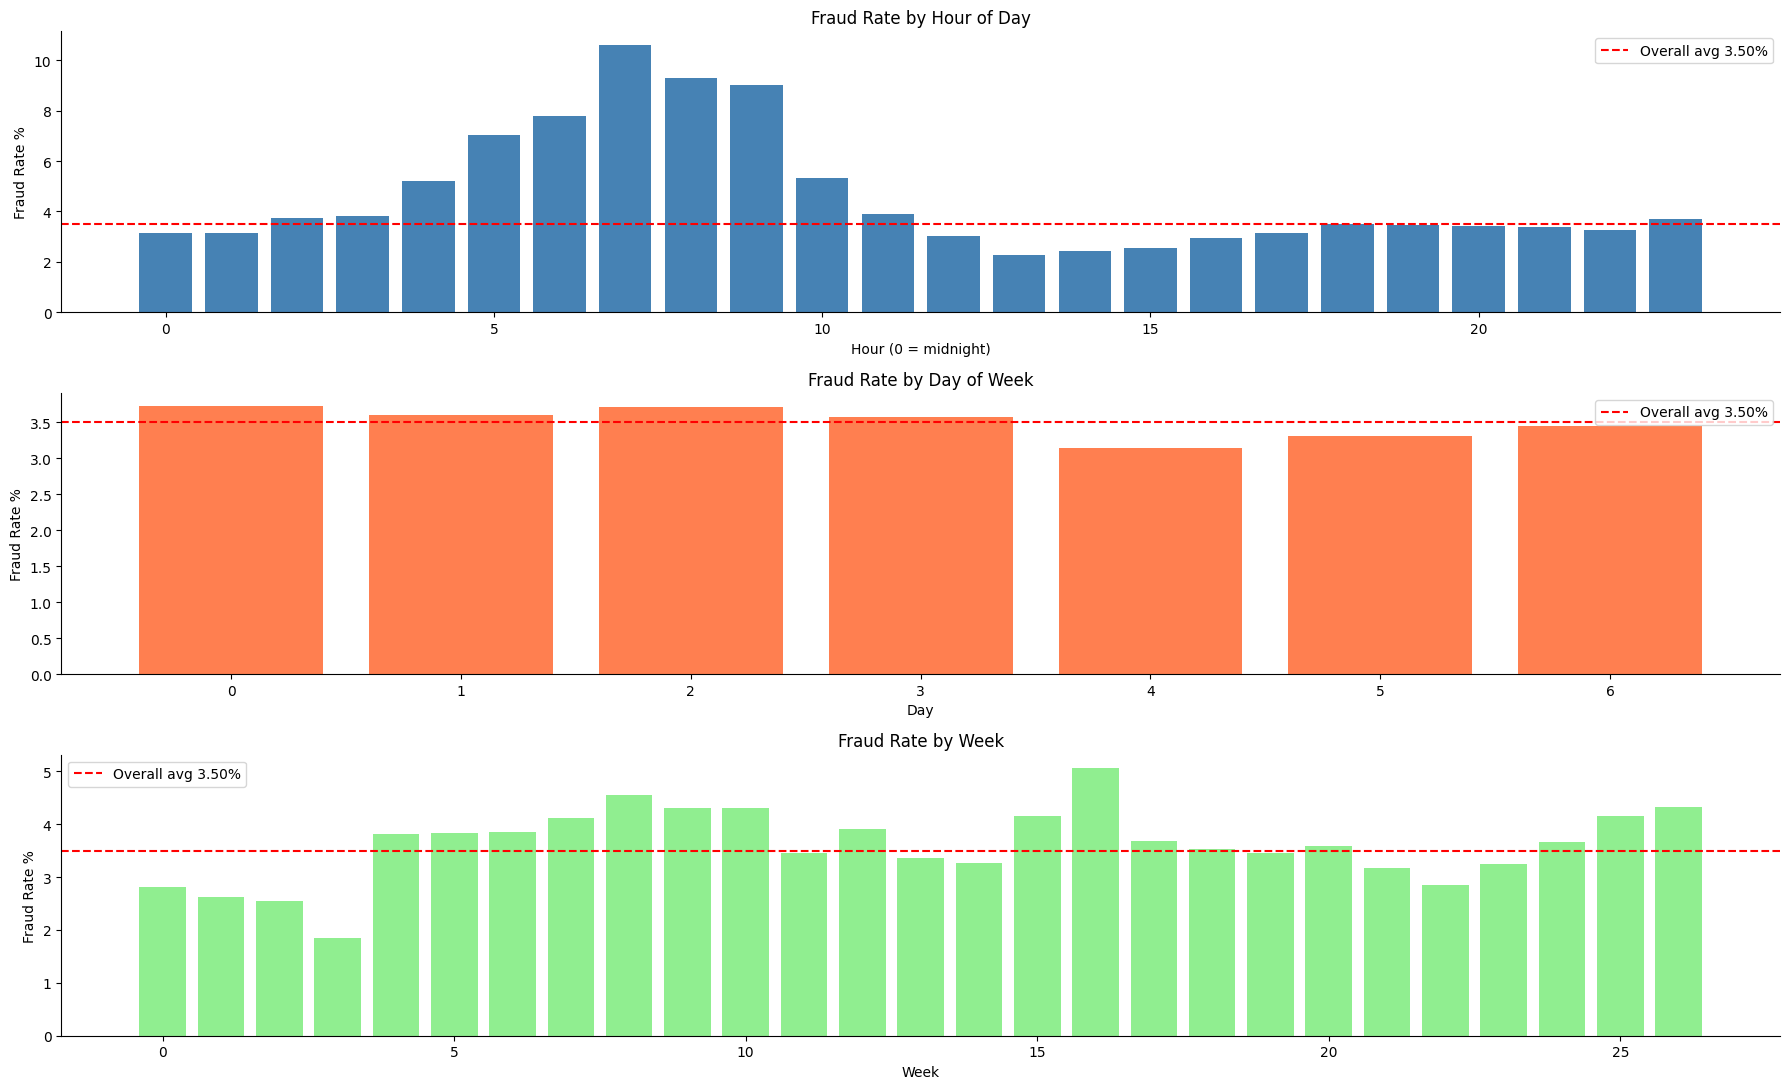

In [70]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = (df['TransactionDT'] // (3600 * 24)) % 7
df['week'] = df['TransactionDT'] // (3600 * 24 * 7)
fig, axes = plt.subplots(3, 1, figsize=(18, 11))

hourly = df.groupby('hour')['isFraud'].mean() * 100
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Fraud Rate %')
axes[0].axhline(y=df['isFraud'].mean()*100, color='red',
                linestyle='--', label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[0].legend()

daily = df.groupby('day')['isFraud'].mean() * 100
axes[1].bar(range(len(daily)), daily.values, color='coral')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate %')
axes[1].axhline(y=df['isFraud'].mean()*100, color='red',
                linestyle='--', label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[1].legend()
    
weekly = df.groupby('week')['isFraud'].mean() * 100
axes[2].bar(range(len(weekly)), weekly.values, color='lightgreen')
axes[2].set_title('Fraud Rate by Week')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Fraud Rate %')
axes[2].axhline(y=df['isFraud'].mean()*100, color='red',
                linestyle='--', label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Categorical Features — Fraud Rate

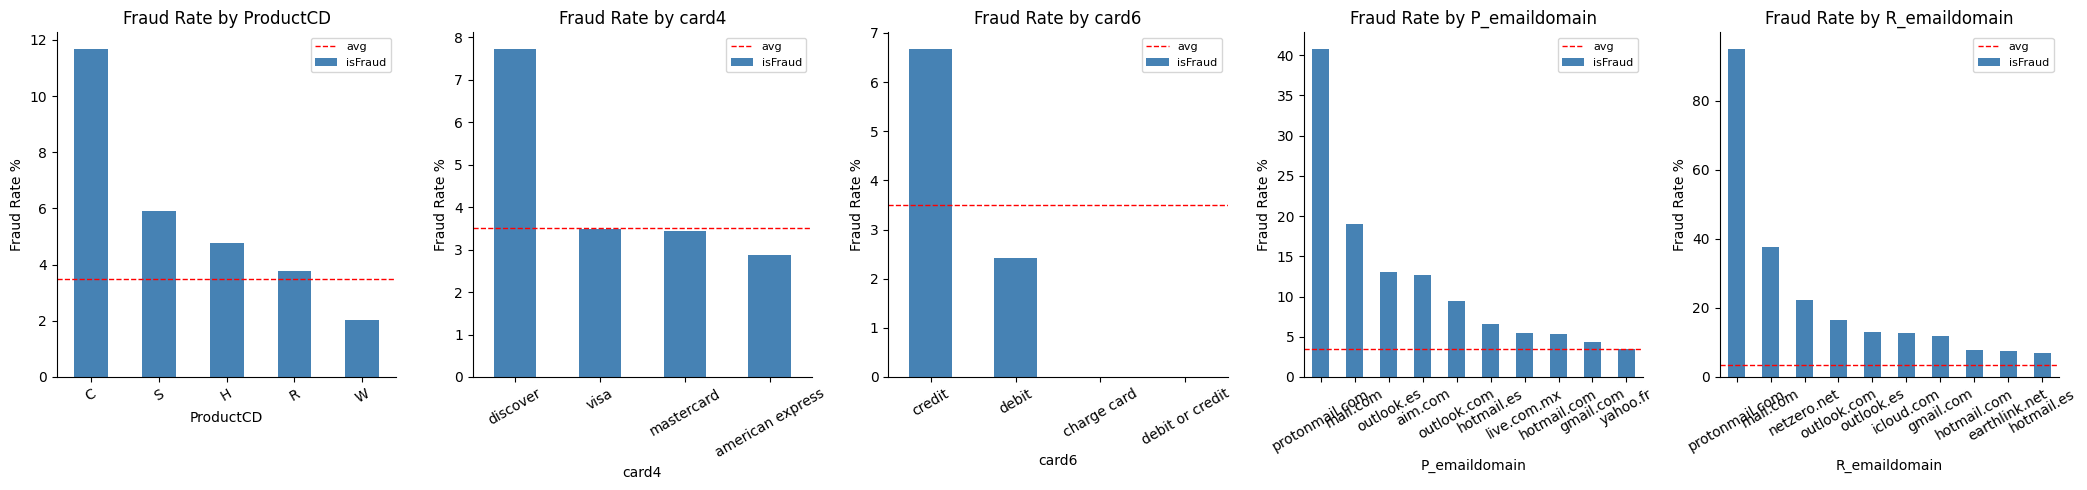

In [72]:
key_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
key_cats = [c for c in key_cats if c in df.columns]

fig, axes = plt.subplots(1 , len(key_cats), figsize=(21, 5))

for i, col in enumerate(key_cats):
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate.head(10).plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fraud Rate %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['isFraud'].mean()*100, color='red',
                    linestyle='--', linewidth=1, label='avg')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. C & D Feature Distributions

C columns (14): ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


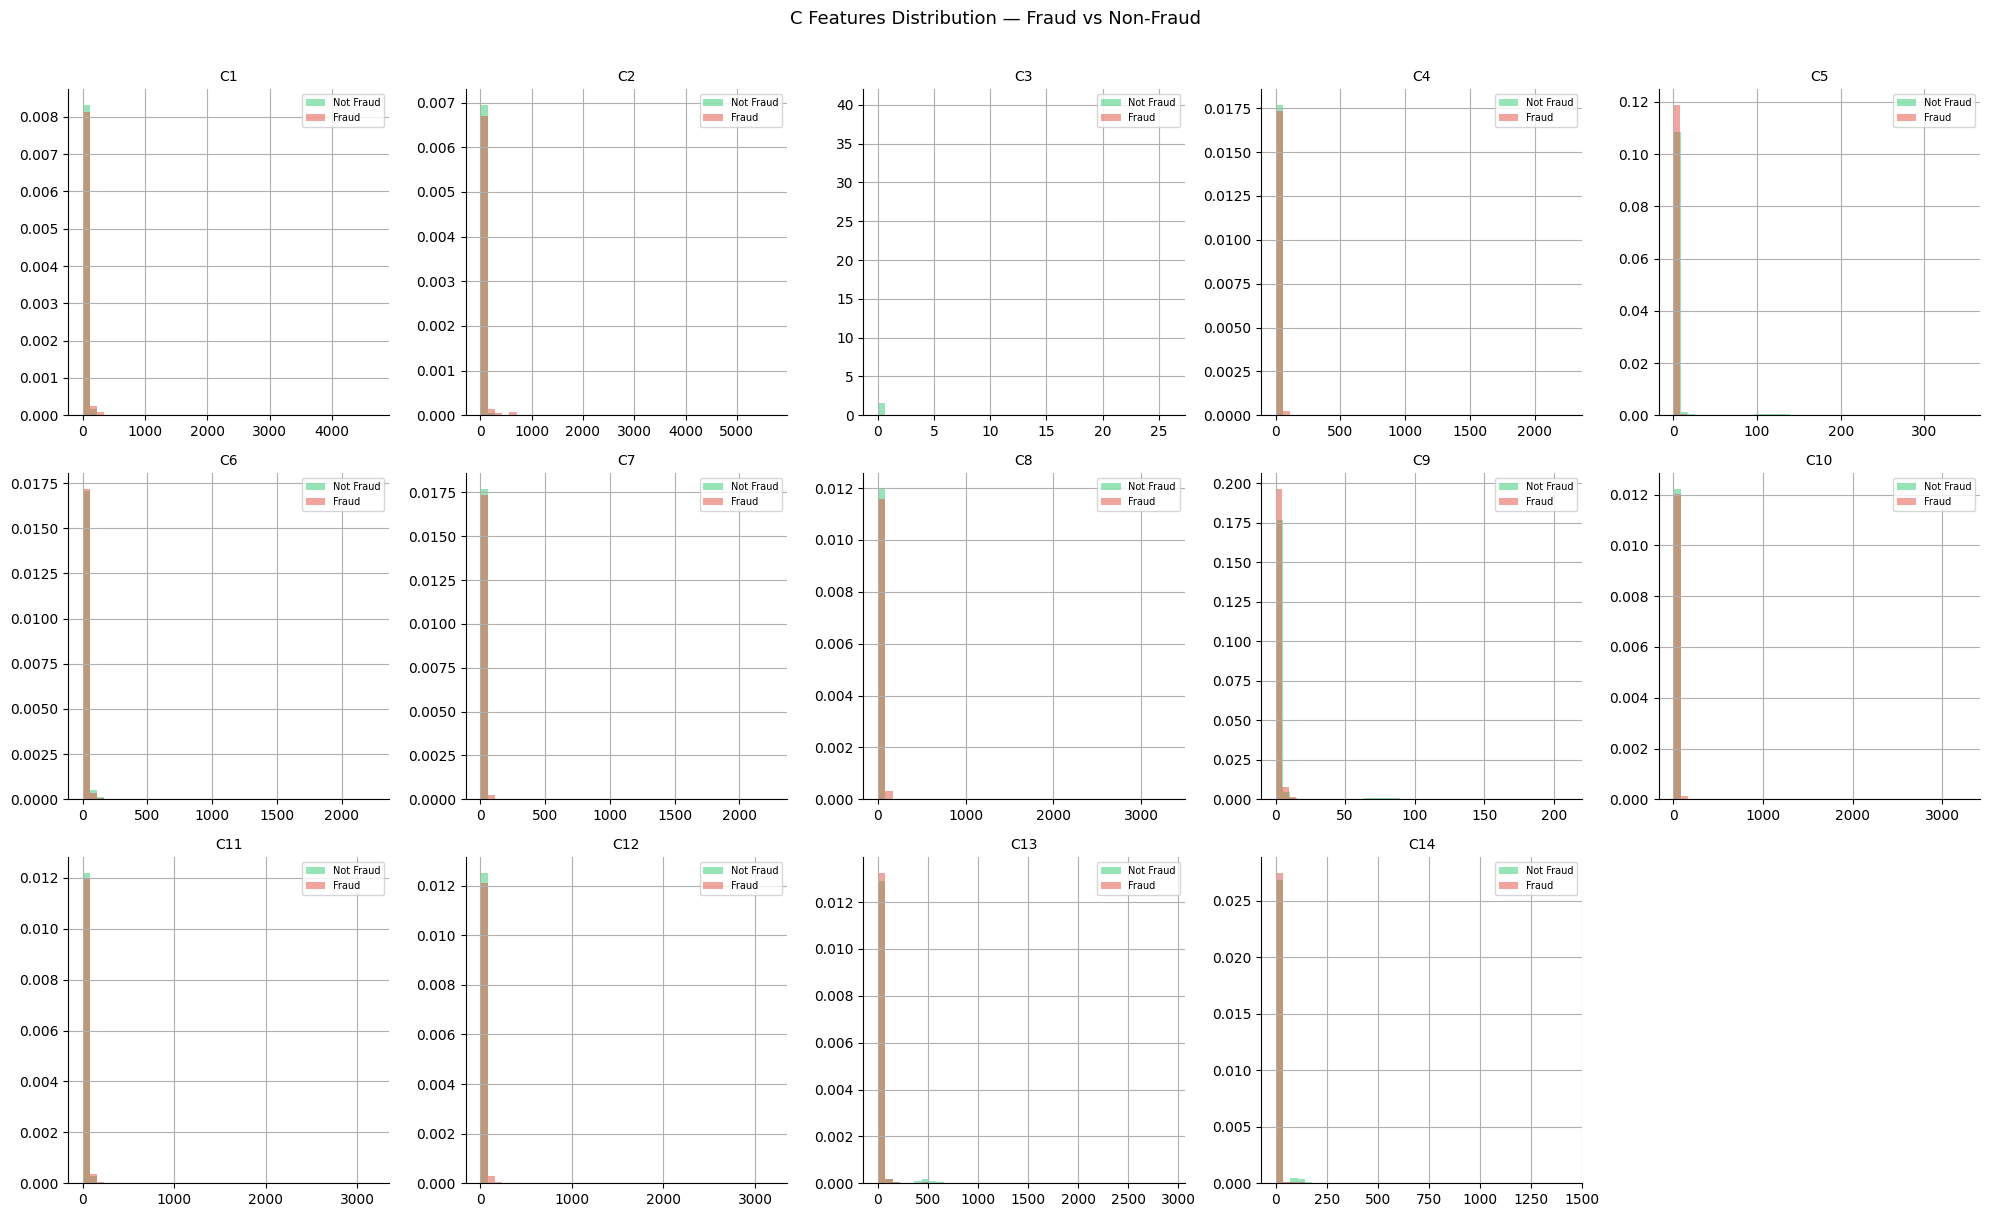

In [73]:
c_cols = [c for c in df.columns if c.startswith('C') and c != 'card4']
print(f'C columns ({len(c_cols)}): {c_cols}')

plot_cols = c_cols[:15]
rows = (len(plot_cols) + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    df[df['isFraud']==0][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#2ecc71', label='Not Fraud', density=True)
    df[df['isFraud']==1][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#e74c3c', label='Fraud', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('C Features Distribution — Fraud vs Non-Fraud', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


D columns (15): ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']


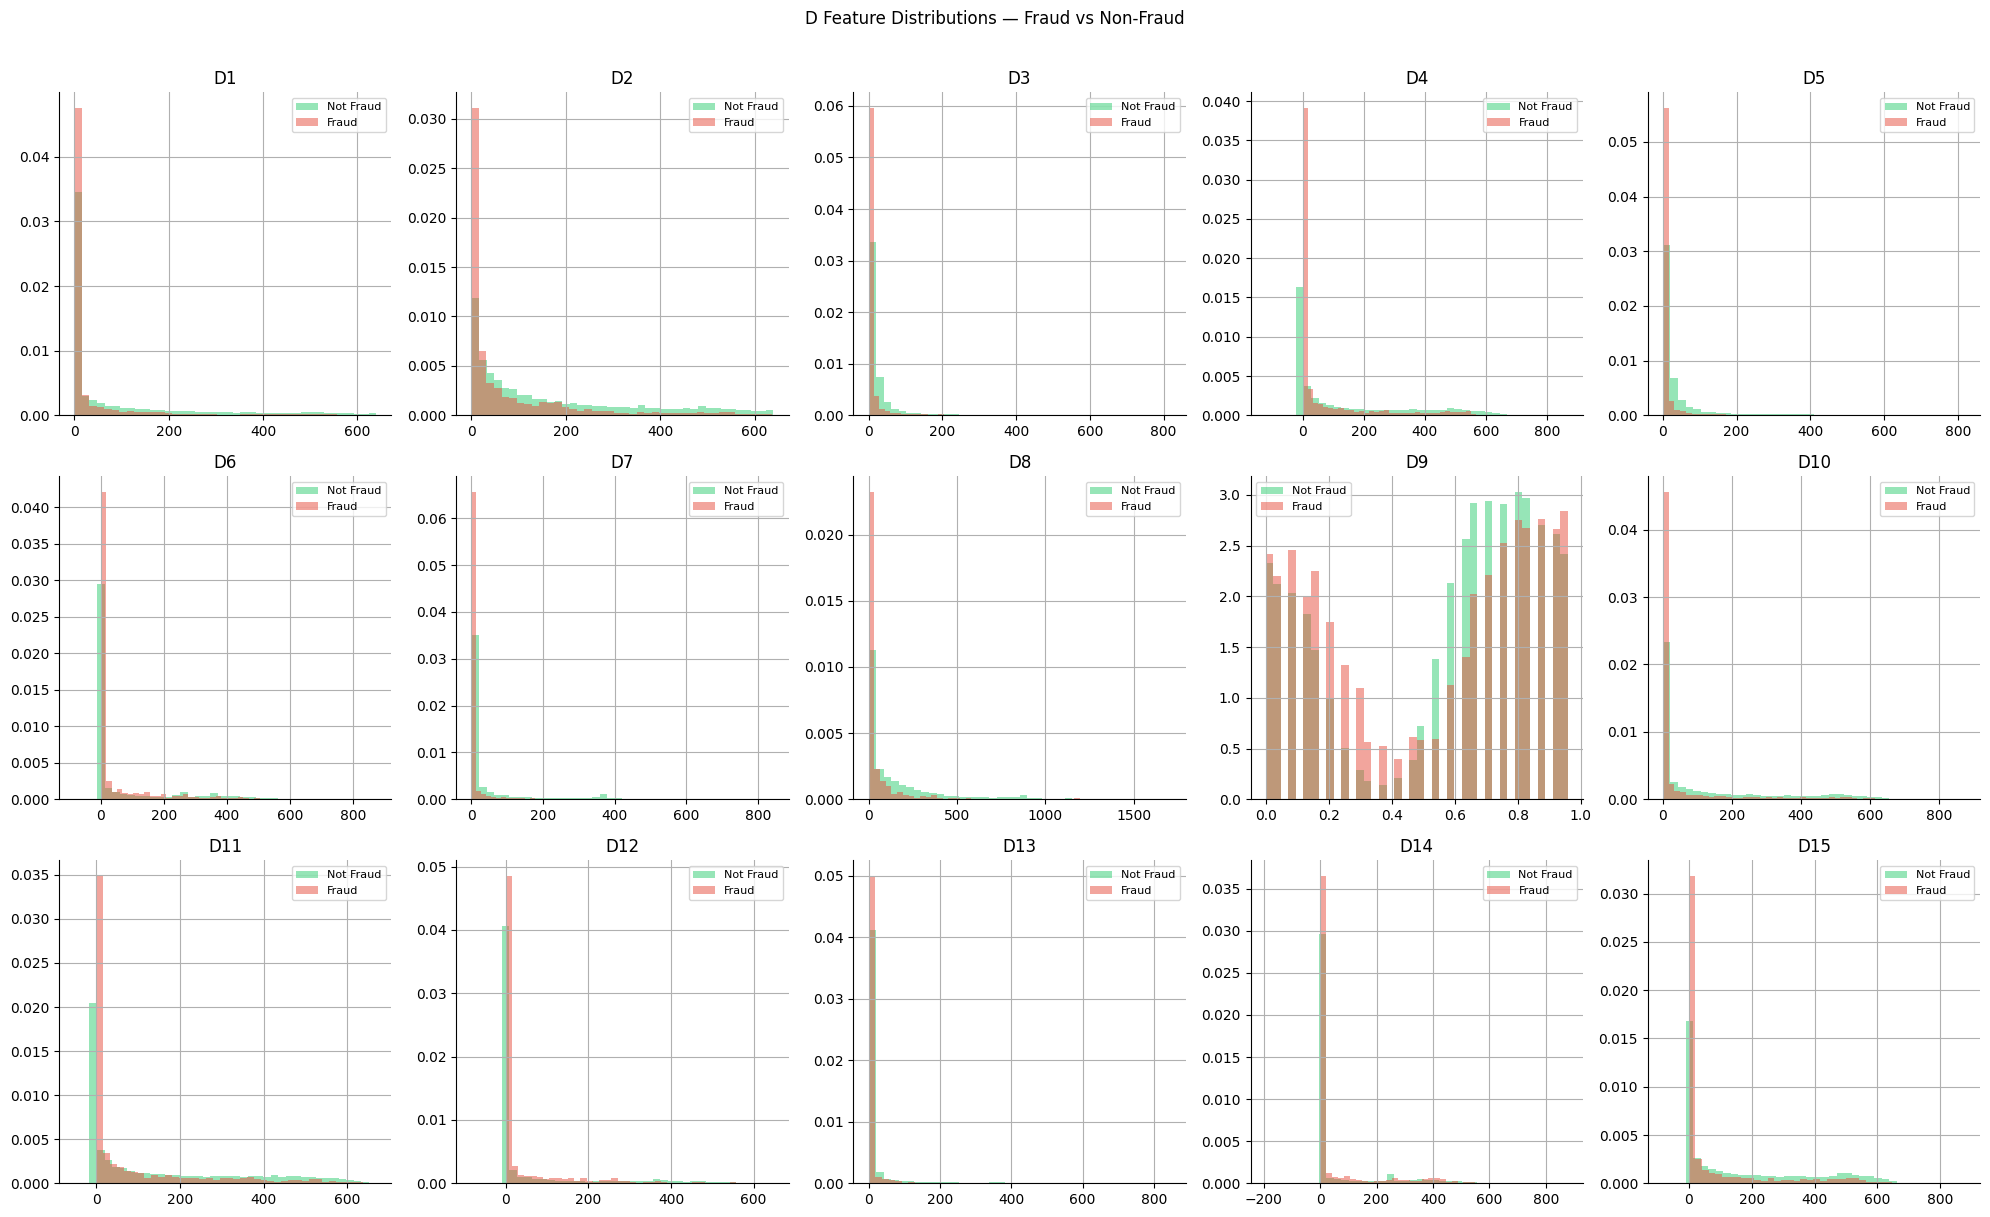

In [74]:
d_cols = [c for c in df.columns if c.startswith('D')]
print(f'\nD columns ({len(d_cols)}): {d_cols}')

plot_d = d_cols[:15]
rows_d = (len(plot_d) + 4) // 5
fig2, axes2 = plt.subplots(rows_d, 5, figsize=(20, rows_d * 4))
axes2 = axes2.flatten()

for i, col in enumerate(plot_d):
    df[df['isFraud']==0][col].hist(bins=40, alpha=0.5, ax=axes2[i],
                                    color='#2ecc71', label='Not Fraud', density=True)
    df[df['isFraud']==1][col].hist(bins=40, alpha=0.5, ax=axes2[i],
                                    color='#e74c3c', label='Fraud', density=True)
    axes2[i].set_title(col)
    axes2[i].legend(fontsize=8)

for j in range(i+1, len(axes2)):
    axes2[j].set_visible(False)
plt.suptitle('D Feature Distributions — Fraud vs Non-Fraud', y=1.01)
plt.tight_layout()
plt.show()

## 9. Correlation with Target

In [ ]:
# Fast: only compute correlation of each feature against target
# Replace the first line only — rest of your cell stays exactly the same
corr_with_target = df[num_cols].corrwith(df['isFraud']).drop('isFraud')
corr_sorted = corr_with_target.abs().sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 9))
colors = ['#e74c3c' if corr_with_target[c] > 0 else '#3498db' for c in corr_sorted.index]
plt.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1])
plt.title('Top 30 Features — Absolute Correlation with isFraud')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

print('Top 10 positively correlated:')
print(corr_with_target.sort_values(ascending=False).head(10))
print('\nTop 10 negatively correlated:')
print(corr_with_target.sort_values(ascending=True).head(10))

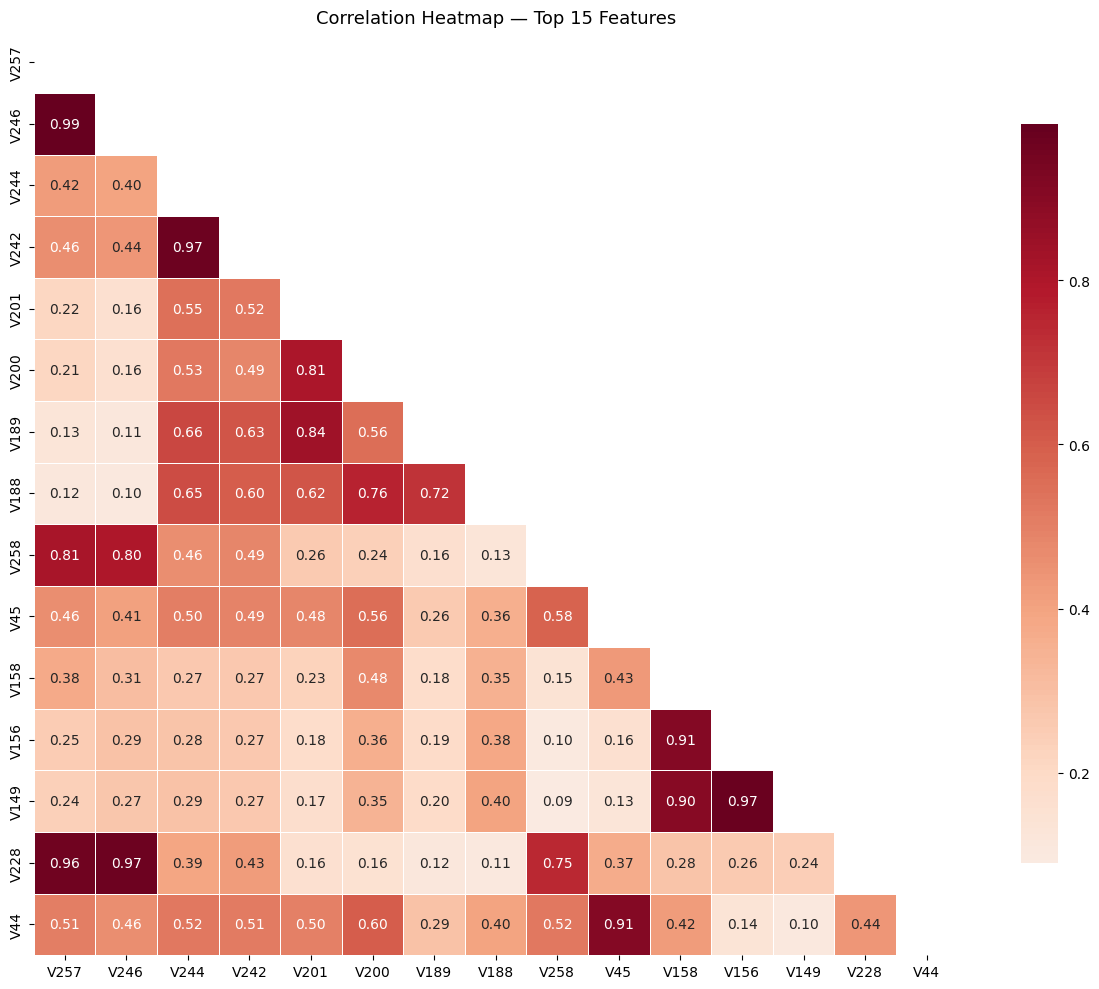

In [76]:
# Heatmap — top 15 most correlated features
top15 = corr_sorted.head(15).index.tolist()
corr_matrix = df[top15].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Top 15 Features', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Outlier Detection

In [77]:
key_num = ['TransactionAmt'] + c_cols[:5]
outlier_report = []

for col in key_num:
    if col not in df.columns:
        continue
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    outlier_report.append({
        'column'       : col,
        'Q1'           : round(Q1, 2),
        'Q3'           : round(Q3, 2),
        'IQR'          : round(IQR, 2),
        'outlier_count': n,
        'outlier_pct'  : round(n / len(df) * 100, 2)
    })

print(pd.DataFrame(outlier_report).to_string(index=False))
print('\nNote: XGBoost is tree-based — robust to outliers, no removal needed')

        column      Q1       Q3     IQR  outlier_count  outlier_pct
TransactionAmt 42.0000 125.0000 83.0000         123078      11.2200
            C1  1.0000   3.0000  2.0000         104687       9.5400
            C2  1.0000   3.0000  2.0000         112651      10.2700
            C3  0.0000   0.0000  0.0000          15338       1.4000
            C4  0.0000   0.0000  0.0000         273774      24.9500
            C5  0.0000   1.0000  1.0000         106610       9.7200

Note: XGBoost is tree-based — robust to outliers, no removal needed


## 11. Feature Keep / Drop Decision

In [78]:
missing_pct       = (df.isnull().sum() / len(df)) * 100
drop_high_missing = missing_pct[missing_pct > 50].index.tolist()
drop_zero_var     = [c for c in df.columns if df[c].nunique() <= 1]
drop_id           = ['TransactionID']

always_keep = [
    'isFraud', 'TransactionDT', 'TransactionAmt',
    'ProductCD', 'card1', 'card2', 'card3', 'card4',
    'card5', 'card6', 'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
    'D1', 'D2', 'D4', 'D10', 'D11'        # critical for client UID — never drop
]

# Safety check: high-null but also high-signal?
high_null_high_signal = [c for c in drop_high_missing if c in corr_sorted.head(30).index]
if high_null_high_signal:
    print(f'High null BUT high signal — consider keeping: {high_null_high_signal}')
else:
    print('  No conflict between high-null and high-signal columns')

all_drops = set(drop_high_missing + drop_zero_var + drop_id) - set(always_keep)
keep_cols  = [c for c in df.columns if c not in all_drops]

print('=== Feature Keep/Drop Decision ===')
print(f'Total columns         : {df.shape[1]}')
print(f'Drop >50% missing     : {len(drop_high_missing)}')
print(f'Drop zero variance    : {len(drop_zero_var)}')
print(f'Drop ID column        : {len(drop_id)}')
print(f'Total columns to DROP : {len(all_drops)}')
print(f'Columns to KEEP       : {len(keep_cols)}')

High null BUT high signal — consider keeping: ['V147', 'V148', 'V149', 'V154', 'V155', 'V156', 'V157', 'V158', 'V170', 'V171', 'V188', 'V189', 'V199', 'V200', 'V201', 'V228', 'V230', 'V242', 'V243', 'V244', 'V246', 'V257', 'V258']
=== Feature Keep/Drop Decision ===
Total columns         : 398
Drop >50% missing     : 173
Drop zero variance    : 0
Drop ID column        : 1
Total columns to DROP : 173
Columns to KEEP       : 225


In [79]:
# Save keep list → artifacts/keep_columns.json
os.makedirs('../artifacts', exist_ok=True)

with open('../artifacts/keep_columns.json', 'w') as f:
    json.dump(keep_cols, f, indent=2)

print('Saved ../artifacts/keep_columns.json ✓')
print('data_transformation.py will read this automatically')

Saved ../artifacts/keep_columns.json ✓
data_transformation.py will read this automatically


## 12. EDA Summary

In [80]:
print('=' * 55)
print('EDA SUMMARY — KEY FINDINGS')
print('=' * 55)
print(f"""
DATASET
  Rows    : {df.shape[0]:,}
  Columns : {df.shape[1]}

CLASS IMBALANCE
  Fraud rate : {df['isFraud'].mean()*100:.2f}%  (severe)
  Fix        : scale_pos_weight in XGBoost
  Metric     : ROC-AUC + F1  (NOT accuracy)

MISSING VALUES
  Columns >50% missing : {len(drop_high_missing)} → DROPPED
  Remaining nulls      : fill median/mode in pipeline

FEATURES
  Columns to keep : {len(keep_cols)}
  Top features    : TransactionAmt, card1-6, C1-C14, D1-D15
  Engineered      : hour, day_of_week from TransactionDT

MODEL
  XGBoost (tabular + imbalanced + handles nulls natively)
  Target  : ROC-AUC > 0.90
""")
print('=' * 55)
print('NEXT STEP → components/data_ingestion.py')
print('=' * 55)

EDA SUMMARY — KEY FINDINGS

DATASET
  Rows    : 1,097,231
  Columns : 398

CLASS IMBALANCE
  Fraud rate : 3.50%  (severe)
  Fix        : scale_pos_weight in XGBoost
  Metric     : ROC-AUC + F1  (NOT accuracy)

MISSING VALUES
  Columns >50% missing : 173 → DROPPED
  Remaining nulls      : fill median/mode in pipeline

FEATURES
  Columns to keep : 225
  Top features    : TransactionAmt, card1-6, C1-C14, D1-D15
  Engineered      : hour, day_of_week from TransactionDT

MODEL
  XGBoost (tabular + imbalanced + handles nulls natively)
  Target  : ROC-AUC > 0.90

NEXT STEP → components/data_ingestion.py


In [87]:


# ── Output folder (sits inside notebooks/) ──────────────────────────
GRAPH_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'EDA_output_Graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(GRAPH_DIR, f'{name}.png'),
                dpi=150, bbox_inches='tight')
    plt.close()

# ── 1. Class Imbalance ───────────────────────────────────────────────
# In your class imbalance cell — add this one line
fraud_counts = df[df['source']=='train']['isFraud'].value_counts()
fraud_pct    = df[df['source']=='train']['isFraud'].value_counts(normalize=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Transactions')
axes[1].pie(fraud_pct.values, labels=['Not Fraud','Fraud'],
            colors=colors, autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')
plt.suptitle('Target — isFraud')
plt.tight_layout()
save_fig('01_class_imbalance')

# ── 2. Missing Value Bucket Bar ──────────────────────────────────────
missing = pd.DataFrame({
    'missing_pct': (df.isnull().sum() / len(df)) * 100
})
missing = missing[missing['missing_pct'] > 0]
buckets = {
    'Low (0-20%)'     : ((missing['missing_pct'] > 0)  & (missing['missing_pct'] <= 20)).sum(),
    'Medium (20-50%)' : ((missing['missing_pct'] > 20) & (missing['missing_pct'] <= 50)).sum(),
    'High (50-80%)'   : ((missing['missing_pct'] > 50) & (missing['missing_pct'] <= 80)).sum(),
    'Very High (>80%)': (missing['missing_pct'] > 80).sum(),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(buckets.keys(), buckets.values(), color=sns.color_palette('Set2'))
axes[0].set_title('Missing Value Distribution by Bucket')
axes[0].set_xlabel('Missing % Bucket')
axes[0].set_ylabel('Column Count')
axes[1].pie(buckets.values(), labels=buckets.keys(),
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Missing Value Pie')
plt.tight_layout()
save_fig('02_missing_value_buckets')

# ── 3. TransactionAmt Distribution ──────────────────────────────────
fraud_amt    = df[df['isFraud']==1]['TransactionAmt']
nonfraud_amt = df[df['isFraud']==0]['TransactionAmt']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(np.log1p(nonfraud_amt), bins=60, alpha=0.6, color='#2ecc71', label='Not Fraud')
axes[0].hist(np.log1p(fraud_amt),    bins=60, alpha=0.6, color='#e74c3c', label='Fraud')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].set_xlabel('log1p(TransactionAmt)')
axes[0].legend()
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_title('Boxplot by Class')
axes[1].set_xlabel('isFraud')
for cls, col, lbl in [(0,'#2ecc71','Not Fraud'),(1,'#e74c3c','Fraud')]:
    vals = np.sort(df[df['isFraud']==cls]['TransactionAmt'].dropna().values)
    axes[2].plot(vals, np.linspace(0,1,len(vals)), label=lbl, color=col)
axes[2].set_title('ECDF — TransactionAmt')
axes[2].set_xlabel('TransactionAmt')
axes[2].legend()
plt.suptitle('Transaction Amount Analysis')
plt.tight_layout()
save_fig('03_transaction_amount')

# ── 4. Time Patterns ─────────────────────────────────────────────────
if 'hour' not in df.columns:
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day']  = (df['TransactionDT'] // (3600*24)) % 7
    df['week'] = df['TransactionDT'] // (3600*24*7)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
hourly = df.groupby('hour')['isFraud'].mean() * 100
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].axhline(y=df['isFraud'].mean()*100, color='red', linestyle='--',
                label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Fraud Rate %')
axes[0].legend()
daily = df.groupby('day')['isFraud'].mean() * 100
axes[1].bar(daily.index, daily.values, color='darkorange')
axes[1].axhline(y=df['isFraud'].mean()*100, color='red', linestyle='--',
                label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[1].set_title('Fraud Rate by Day Cycle (0–6, relative)')
axes[1].set_xlabel('Day Cycle')
axes[1].set_ylabel('Fraud Rate %')
axes[1].legend()
weekly = df.groupby('week')['isFraud'].mean() * 100
axes[2].bar(weekly.index, weekly.values, color='lightgreen')
axes[2].axhline(y=df['isFraud'].mean()*100, color='red', linestyle='--',
                label=f'Overall avg {df["isFraud"].mean()*100:.2f}%')
axes[2].set_title('Fraud Rate by Week')
axes[2].set_xlabel('Week')
axes[2].set_ylabel('Fraud Rate %')
axes[2].legend()

plt.tight_layout()
save_fig('04_time_patterns')

# ── 5. Categorical Fraud Rates ────────────────────────────────────────
key_cats = [c for c in ['ProductCD','card4','card6','P_emaildomain','R_emaildomain']
            if c in df.columns]
fig, axes = plt.subplots(1, len(key_cats), figsize=(22, 5))
for i, col in enumerate(key_cats):
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate.head(10).plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fraud Rate %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['isFraud'].mean()*100, color='red', linestyle='--')
plt.suptitle('Categorical Feature — Fraud Rates')
plt.tight_layout()
save_fig('05_categorical_fraud_rates')

# ── 6. C Feature Distributions ───────────────────────────────────────
c_cols = [c for c in df.columns if c.startswith('C') and c != 'card4']
plot_cols = c_cols[:15]
rows = (len(plot_cols) + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(20, rows*4))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    df[df['isFraud']==0][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#2ecc71', label='Not Fraud', density=True)
    df[df['isFraud']==1][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#e74c3c', label='Fraud', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('C Feature Distributions — Fraud vs Non-Fraud', y=1.01)
plt.tight_layout()
save_fig('06_C_feature_distributions')

# ── 7. D Feature Distributions ───────────────────────────────────────
d_cols = [c for c in df.columns if c.startswith('D')]
plot_d = d_cols[:15]
rows_d = (len(plot_d) + 4) // 5
fig, axes = plt.subplots(rows_d, 5, figsize=(20, rows_d*4))
axes = axes.flatten()
for i, col in enumerate(plot_d):
    df[df['isFraud']==0][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#2ecc71', label='Not Fraud', density=True)
    df[df['isFraud']==1][col].hist(bins=40, alpha=0.5, ax=axes[i],
                                    color='#e74c3c', label='Fraud', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('D Feature Distributions — Fraud vs Non-Fraud', y=1.01)
plt.tight_layout()
save_fig('07_D_feature_distributions')

# ── 8. Correlation Bar Chart ─────────────────────────────────────────
corr_with_target = df[num_cols].corrwith(df['isFraud']).drop('isFraud')
corr_sorted = corr_with_target.abs().sort_values(ascending=False).head(30)
plt.figure(figsize=(10, 9))
colors = ['#e74c3c' if corr_with_target[c] > 0 else '#3498db' for c in corr_sorted.index]
plt.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1])
plt.title('Top 30 Features — Absolute Correlation with isFraud')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
save_fig('08_correlation_with_target')

# ── 9. Correlation Heatmap ───────────────────────────────────────────
top15 = corr_sorted.head(15).index.tolist()
corr_matrix = df[top15].corr()
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top 15 Features')
plt.tight_layout()
save_fig('09_correlation_heatmap')

print(f'✓ All graphs saved to: {GRAPH_DIR}')

✓ All graphs saved to: d:\Fraud-Detection\Project-One\notebooks\EDA_output_Graphs


In [82]:
# ── Output path: notebooks/data/EDA_summary.txt ─────────────────────
SUMMARY_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data')
os.makedirs(SUMMARY_DIR, exist_ok=True)
SUMMARY_PATH = "D:\\Fraud-Detection\\Project-One\\notebooks\\data\\EDA_summary.txt"

missing_pct       = (df.isnull().sum() / len(df)) * 100
drop_high_missing = missing_pct[missing_pct > 50].index.tolist()
fraud_counts      = df['isFraud'].value_counts()
fraud_pct         = df['isFraud'].value_counts(normalize=True) * 100
fraud_amt         = df[df['isFraud']==1]['TransactionAmt']
nonfraud_amt      = df[df['isFraud']==0]['TransactionAmt']

summary = f"""
================================================================================
IEEE-CIS FRAUD DETECTION — TRANSACTION DATASET EDA SUMMARY
================================================================================

DATASET OVERVIEW
----------------
  Total rows          : {df.shape[0]:,}
  Total columns       : {df.shape[1]}
  Numeric columns     : {len(num_cols)}
  Categorical columns : {len(cat_cols)}
  Categorical cols    : {cat_cols}
  Source              : Combined train + test → transaction.parquet (read-only)

DTYPES BREAKDOWN
----------------
  float64 : 377 columns  (V features, C/D/M cols, card2/3/5, amounts)
  object  : 14 columns   (ProductCD, card4, card6, email domains, M1–M9)
  int64   : 3 columns    (TransactionID, TransactionDT, isFraud)

MISSING VALUES
----------------
  Columns with any null    : 389 / {df.shape[1]}
  Columns dropped (>50%)   : {len(drop_high_missing)}
  Worst missing columns:
    dist2  → 93.25%  (dropped)
    D7     → 90.97%  (dropped)
    D12    → 87.79%  (dropped)
    D8/D9  → 86.40%  (dropped)
    V138–V163 group → 85.62% (dropped)
  Strategy: drop >50% null | always_keep protects D1/D2/D4/D10/D11 + core cols
  Remaining nulls: fill with median (numeric) / mode (categorical) in pipeline

CLASS IMBALANCE
----------------
  Not Fraud (0) : {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)
  Fraud     (1) : {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)
  Imbalance ratio : {fraud_counts[0]/fraud_counts[1]:.1f} : 1  (SEVERE)
  Fix             : scale_pos_weight = {fraud_counts[0]/fraud_counts[1]:.1f} in XGBoost
  Metric          : ROC-AUC + F1  — NOT accuracy

TRANSACTION AMOUNT ANALYSIS
-----------------------------
  Not Fraud — mean: ${nonfraud_amt.mean():.2f}  median: ${nonfraud_amt.median():.2f}  max: ${nonfraud_amt.max():.2f}
  Fraud     — mean: ${fraud_amt.mean():.2f}  median: ${fraud_amt.median():.2f}  max: ${fraud_amt.max():.2f}
  Distribution is heavily right-skewed → log1p transform applied for plots
  Insight: Fraud mean is slightly higher but distributions heavily overlap.
           TransactionAmt alone is a WEAK fraud signal.

TIME PATTERN ANALYSIS
----------------------
  TransactionDT is relative seconds offset (no known epoch — not a real timestamp)
  Engineered features:
    hour = (TransactionDT // 3600) % 24
    day  = (TransactionDT // 86400) % 7    ← relative day cycle, NOT true day-of-week
    week = TransactionDT // 604800          ← week number from dataset start
  Insight: Fraud rate spikes in late-night / early-morning hours above 3.5% baseline.
           Day cycle shows minor variation — week useful for train/test drift detection.

CATEGORICAL FEATURE INSIGHTS
------------------------------
  ProductCD  : 5 categories (W/H/C/S/R). Fraud rate varies significantly by product.
  card4      : Visa/Mastercard/Discover/Amex. Some networks show higher fraud rate.
  card6      : debit vs credit. Debit cards tend to show different fraud patterns.
  P_emaildomain : Buyer email domain — certain domains correlate with higher fraud.
  R_emaildomain : Seller email domain — useful signal, ~25% null.

C FEATURE INSIGHTS (C1–C14)
-----------------------------
  C columns are masked count features (e.g. number of addresses on card).
  All 14 retained (low–moderate nulls).
  C3 behaves differently from C1/C2/C4–C14 — less intercorrelated.
  Distributions differ between fraud/non-fraud classes — useful signal.
  High intercorrelation within group expected.

D FEATURE INSIGHTS (D1–D15)
-----------------------------
  D columns are time-delta features (days between events).
  D1  : Days since card first used — MOST IMPORTANT D feature.
        Used with card1 + addr1 to build client UID in feature engineering.
  D2/D4/D10/D11 : Days between transactions — low nulls, high signal.
  D6/D7/D8/D9/D12–D14 : 87–93% null — DROPPED.
  Always protected in always_keep list regardless of null %.

CORRELATION WITH TARGET (isFraud)
-----------------------------------
  Method: corrwith() — efficient, avoids full 380x380 matrix.
  Top signals come from V columns and select C/D columns.
  No single feature dominates strongly.
  Model must combine many weak signals → ensemble tree methods ideal.
  Positive correlators (higher value → more fraud): V features, some C cols.
  Negative correlators (higher value → less fraud): select D/V features.

OUTLIER ANALYSIS
-----------------
  Method: IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR) on TransactionAmt + C1–C5.
  High outlier counts detected in TransactionAmt and C columns.
  Decision: NO removal — XGBoost is tree-based and robust to outliers.

FEATURE KEEP / DROP DECISION
------------------------------
  Total columns         : {df.shape[1]}
  Dropped (>50% null)   : {len(drop_high_missing)}
  Dropped (zero variance): columns with nunique <= 1
  Dropped (ID col)      : TransactionID
  Always kept           : isFraud, TransactionDT, TransactionAmt, ProductCD,
                          card1–card6, addr1, addr2, P_emaildomain, R_emaildomain,
                          D1, D2, D4, D10, D11
  Final keep list saved : artifacts/keep_columns.json

MODEL DIRECTION
----------------
  Algorithm : XGBoost (handles nulls natively, robust to outliers, fast on tabular)
  Target    : ROC-AUC > 0.90
  class_weight: scale_pos_weight = {fraud_counts[0]/fraud_counts[1]:.1f}
  CV strategy : Time-based split — NO random shuffle (train/test are time-ordered)
  Next step   : Identity dataset EDA → Merge → Feature Engineering → Pipeline

================================================================================
END OF EDA SUMMARY
================================================================================
"""

with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    f.write(summary)

print(f' EDA summary saved to: {SUMMARY_PATH}')

 EDA summary saved to: D:\Fraud-Detection\Project-One\notebooks\data\EDA_summary.txt


In [88]:
df.shape

(1097231, 398)